In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [ ]:
import kagglehub as kh

data_path = kh.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")

df = pd.read_csv(data_path + "/2022/heart_2022_no_nans.csv")
df.shape

100%|██████████| 21.4M/21.4M [00:02<00:00, 10.5MB/s]


Extracting files...


(246022, 40)

In [ ]:
df.head(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HeartDisease
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No,0
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No,0
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,0
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,0
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
5,Alabama,Male,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,120.20,34.96,Yes,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
6,Alabama,Female,Good,3.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,"6 or more, but not all",No,...,88.00,33.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
7,Alabama,Male,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,Yes,...,74.84,24.37,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1
8,Alabama,Male,Good,2.0,0.0,5 or more years ago,No,6.0,None of them,No,...,78.02,26.94,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
9,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,63.50,22.60,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  object 
 1   Sex                        246022 non-null  object 
 2   GeneralHealth              246022 non-null  object 
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  object 
 6   PhysicalActivities         246022 non-null  object 
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  object 
 9   HadHeartAttack             246022 non-null  object 
 10  HadAngina                  246022 non-null  object 
 11  HadStroke                  246022 non-null  object 
 12  HadAsthma                  246022 non-null  object 
 13  HadSkinCancer              24

In [ ]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000
mean,4.119026,4.167140,7.021331,1.705150,83.615179,28.668136
std,8.405844,8.102687,1.440681,0.106654,21.323156,6.513973
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
       'HeightInMeters', 'WeightInKilograms', 'BMI'],
      dtype='object')


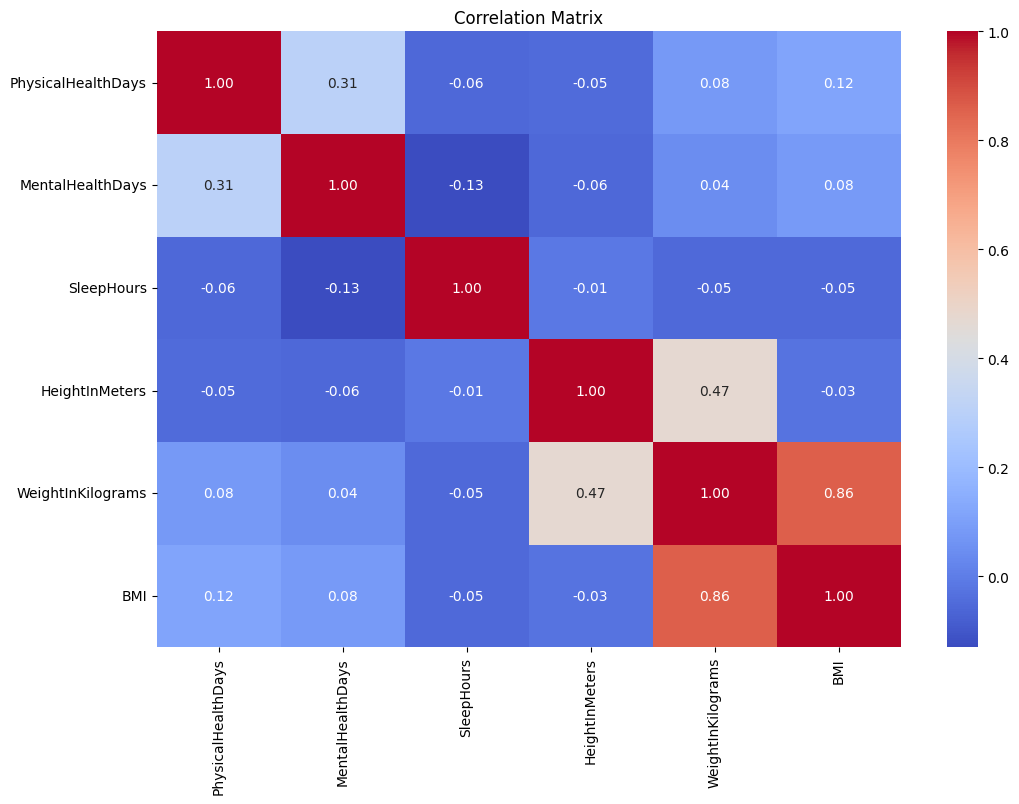

In [ ]:

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

1. Weight and BMI: Very Strong Positive Correlation (0.86)
2. Height and Weight: Moderate Positive Correlation (0.47)
3. Physical Health and Mental Health Days: Weak-to-Moderate Positive Correlation (0.31)
4. Higher BMI is slightly associated with poorer health.
The relationship is weak by itself.

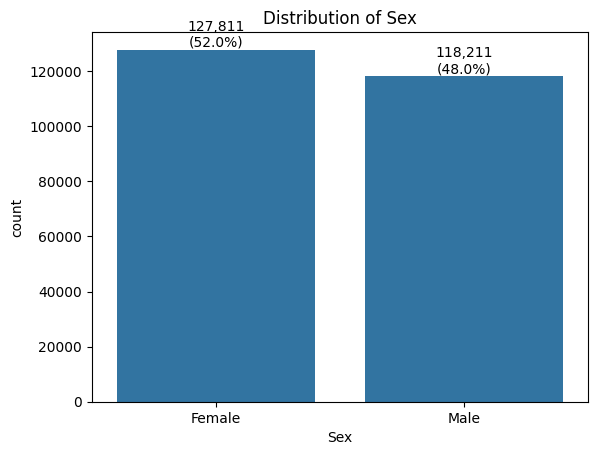

In [ ]:
ax = sns.countplot(data=df, x='Sex')

total = len(df)

for container in ax.containers:
    labels = [
        f'{v.get_height():,.0f}\n({v.get_height()/total*100:.1f}%)'
        for v in container
    ]
    ax.bar_label(container, labels=labels)

plt.title('Distribution of Sex')
plt.show()

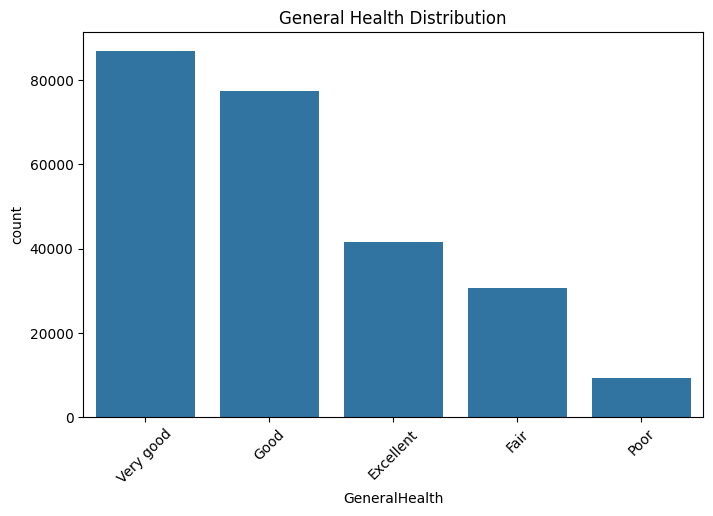

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='GeneralHealth',
    order=df['GeneralHealth'].value_counts().index
)

plt.title('General Health Distribution')
plt.xticks(rotation=45)
plt.show()
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

print(cat_cols)

Index(['State', 'Sex', 'GeneralHealth', 'LastCheckupTime',
       'PhysicalActivities', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')


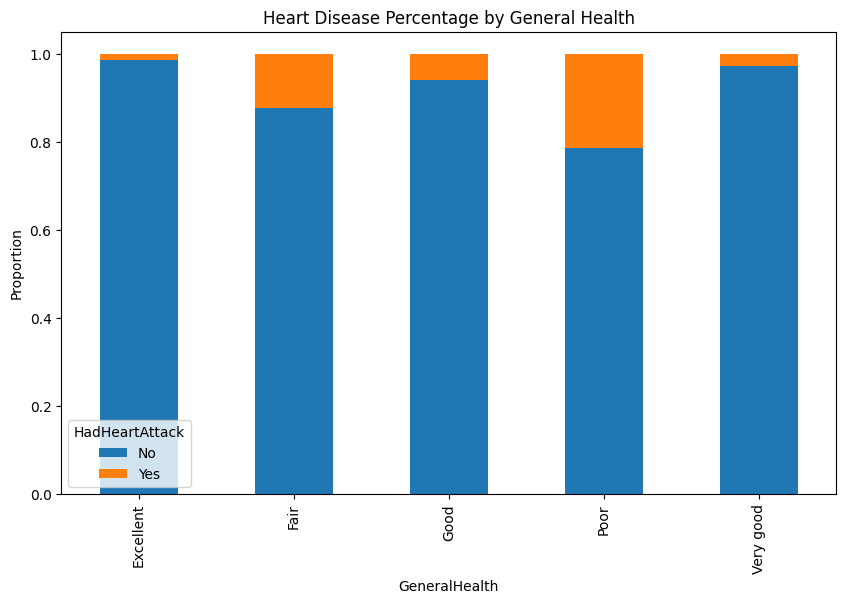

In [ ]:
pd.crosstab(
    df['GeneralHealth'],
    df['HadHeartAttack'],
    normalize='index'
).plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Heart Disease Percentage by General Health')
plt.ylabel('Proportion')
plt.show()

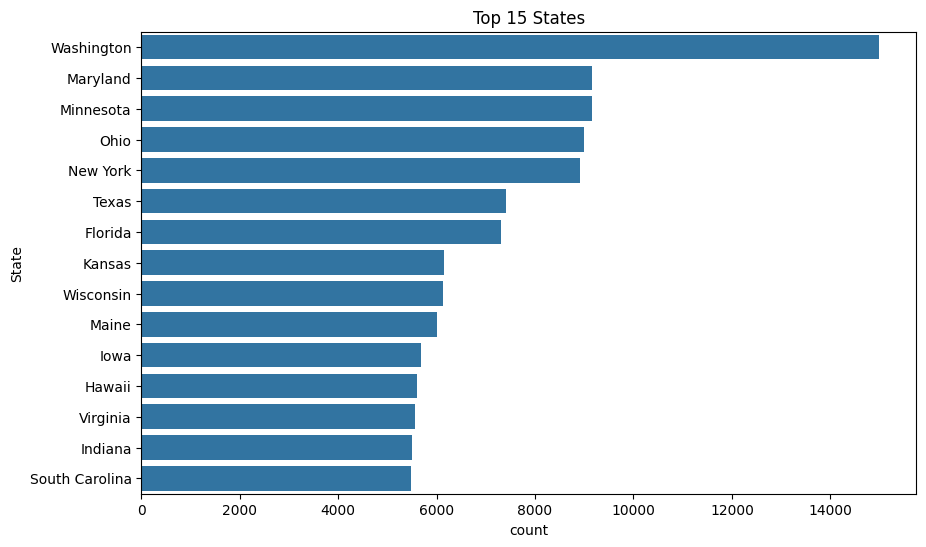

In [ ]:
top_states = df['State'].value_counts().head(15).index

plt.figure(figsize=(10,6))

sns.countplot(
    data=df[df['State'].isin(top_states)],
    y='State',
    order=top_states
)

plt.title('Top 15 States')
plt.show()

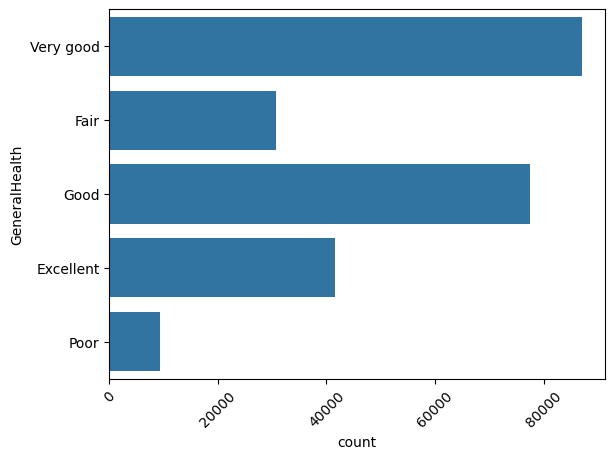

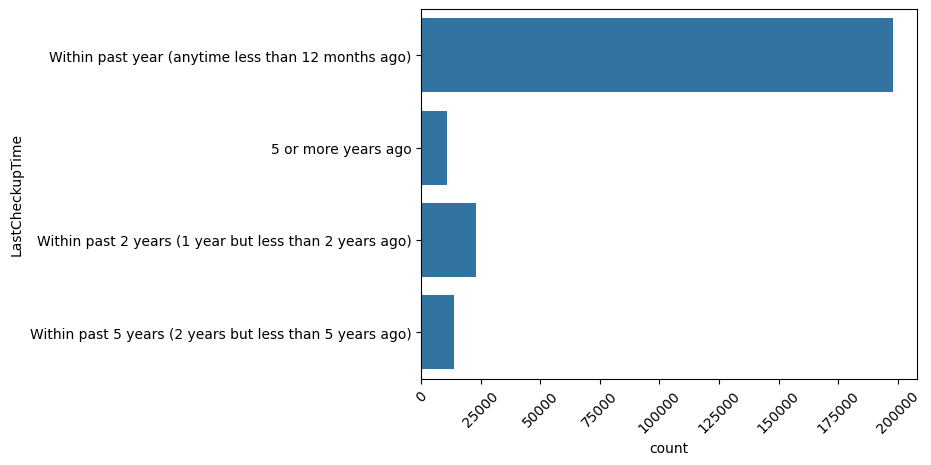

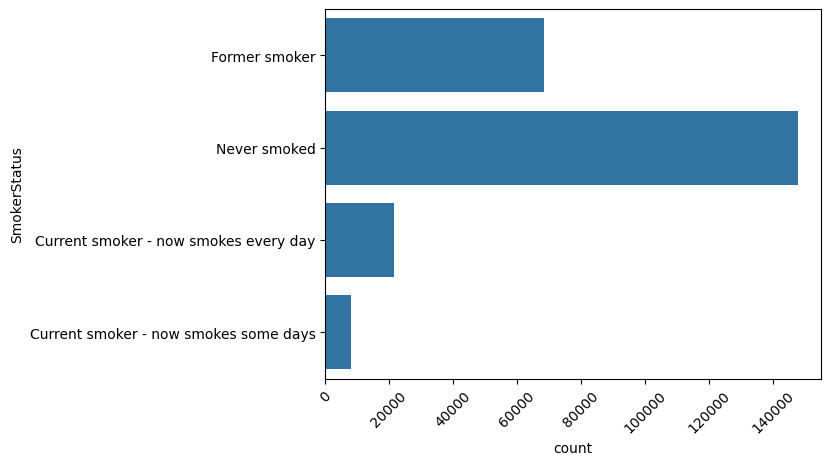

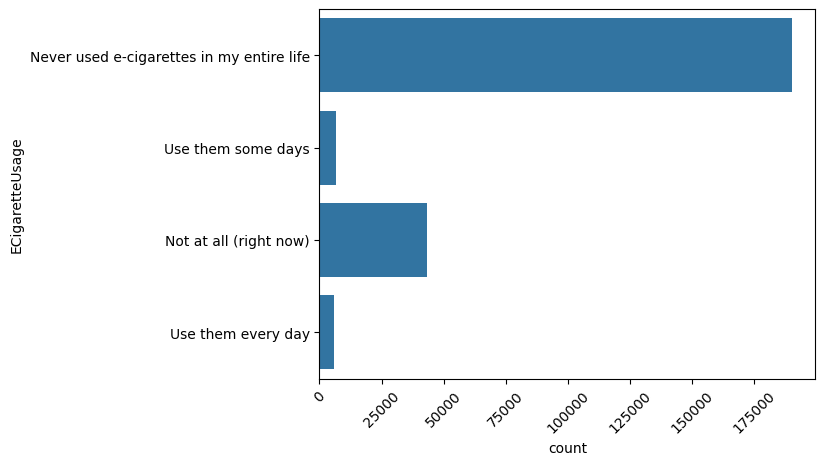

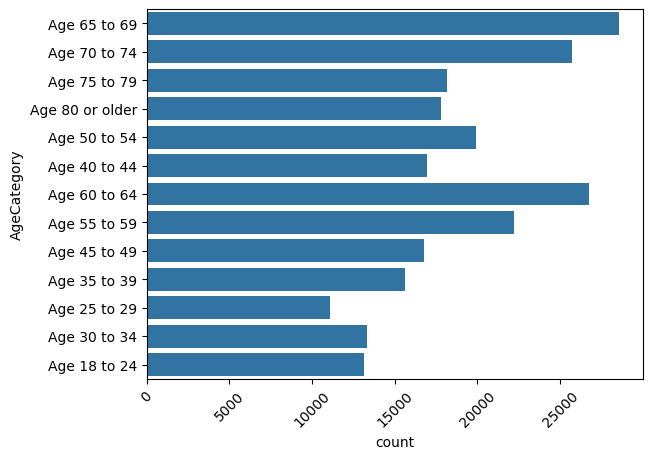

In [ ]:
important_cols = [
    'GeneralHealth',
    'LastCheckupTime',
    'SmokerStatus',
    'ECigaretteUsage',
    'AgeCategory'
]

for col in important_cols:
    sns.countplot(
        data=df,
        y=col,

    )

    plt.xticks(rotation=45)
    plt.show()

**Feature Engineering**

In [ ]:
# create a target variable

df['HeartDisease'] = np.where((df['HadHeartAttack'] == 'Yes') | (df['HadAngina'] == 'Yes'), 1, 0)
df['HeartDisease'].unique()

array([0, 1])

In [ ]:
# seperate features from target
X = df.drop(columns=['HeartDisease', 'HadHeartAttack', 'HadAngina'])
y = df['HeartDisease']

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

print(categorical_cols)
print(numeric_features)

Index(['State', 'Sex', 'GeneralHealth', 'LastCheckupTime',
       'PhysicalActivities', 'RemovedTeeth', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AgeCategory', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12',
       'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')
Index(['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
       'HeightInMeters', 'WeightInKilograms', 'BMI'],
      dtype='object')


In [ ]:
# preprocessing of X

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
       'HeightInMeters', 'WeightInKilograms', 'BMI'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(...
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AgeCategory', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12',
       'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object'))])

In [ ]:
X.shape

(246022, 38)

In [ ]:
X_processed_df = pd.DataFrame(
    preprocessor.fit_transform(X),
    columns=preprocessor.get_feature_names_out()
)

In [ ]:
X_transformed = preprocessor.fit_transform(X)

print(type(X_transformed))
print(X_transformed.shape)
print(len(preprocessor.get_feature_names_out()))

<class 'numpy.ndarray'>
(246022, 152)
152


In [ ]:
X_processed_df = pd.DataFrame(
    X_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X.index
)

X_processed_df.head()

,num__PhysicalHealthDays,num__MentalHealthDays,num__SleepHours,num__HeightInMeters,num__WeightInKilograms,num__BMI,cat__State_Alabama,cat__State_Alaska,cat__State_Arizona,cat__State_Arkansas,...,cat__PneumoVaxEver_Yes,"cat__TetanusLast10Tdap_No, did not receive any tetanus shot in the past 10 years","cat__TetanusLast10Tdap_Yes, received Tdap","cat__TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","cat__TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",cat__HighRiskLastYear_No,cat__HighRiskLastYear_Yes,cat__CovidPos_No,cat__CovidPos_Tested positive using home test without a health professional,cat__CovidPos_Yes
0,-0.014160,-0.514292,1.373428,-0.985904,-0.560199,-0.104105,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.490020,-0.514292,-0.708924,0.701799,0.545644,0.224420,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.490020,-0.514292,0.679311,1.358128,1.183918,0.459300,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.104805,-0.514292,1.373428,-0.048291,0.333198,0.407105,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.133125,1.336949,-1.403041,-1.454710,-0.198619,0.675759,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
X_processed_df.shape


(246022, 152)

now that we have process our dataset, we need to split the dataset into **Training and Test Dataset**

In [ ]:
y.dtype

dtype('int64')

In [ ]:
# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed,
    np.array(y, dtype=float),
    test_size=0.30,
    random_state=42,

)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Y_train set:", y_train.shape)

Training set: (172215, 152)
Test set: (73807, 152)
Y_train set: (172215,)


Now we write our Logistics **Regression Function**

In [ ]:
# Vectorized Implementation of Logistic Regression

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_train_gd(X, y, lr=0.1, epochs=1000, l2=0.0, tol=1e-6, verbose=False):
    """
    X: (N, d) input features (should include bias column if you want bias in weights)
    y: (N,) binary labels 0/1
    """
    N, d = X.shape
    w = np.zeros(d)            # w sometimes theta (𝜃)
    prev_loss = np.inf
    losses = []

    start = time.time()

    for epoch in range(epochs):
        # Prediction
        z = X.dot(w)               # (N,)
        p = sigmoid(z)             # (N,)

        # Loss (average logistic loss)
        eps = 1e-12   # eps (epsilon) is a very low value used to avoid divide-by-zero or log of zero errors.
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)) + 0.5 * l2 * np.sum(w**2) # the last term is called L2 regularization

        # Gradient
        grad = (X.T.dot(p - y)) / N + l2 * w  # Shape is (d,N). Last term is L2 regularization.

        # Parameter update
        w -= lr * grad

        # Stopping condition: stop if difference btw current loss and prev loss is less than 'tol'.
        if abs(prev_loss - loss) < tol:
            if verbose:
                print(f"Converged at epoch {epoch}, loss={loss:.6f}")
            break
        prev_loss = loss
        losses.append(loss)

        if verbose and (epoch % 100 == 0):
            print(f"Epoch {epoch:4d}, loss={loss:.6f}")

    end = time.time()
    print(f"Time taken: {end - start} seconds")

    return w, losses


here we add a column of 1's at the beginning of X to act as the bias term

In [ ]:
# Add a column of 1's at the beginning of X to act as the bias term
X_trainN = np.hstack([np.ones((X_train.shape[0],1)), X_train])
X_testN = np.hstack([np.ones((X_test.shape[0],1)), X_test])

print(X_trainN.shape)
print(X_testN.shape)

(172215, 153)
(73807, 153)


Now we can train our model

In [ ]:
# Train using the above logistic function.
w, losses = logistic_train_gd(X_trainN, y_train, lr=0.1, epochs=1_000_000, l2=1e-4, verbose=True)

Epoch    0, loss=0.693147
Epoch  100, loss=0.248623
Epoch  200, loss=0.240781
Epoch  300, loss=0.237657
Epoch  400, loss=0.235973
Epoch  500, loss=0.234886
Epoch  600, loss=0.234104
Epoch  700, loss=0.233504
Epoch  800, loss=0.233022
Epoch  900, loss=0.232623
Epoch 1000, loss=0.232285
Epoch 1100, loss=0.231994
Epoch 1200, loss=0.231738
Epoch 1300, loss=0.231511
Epoch 1400, loss=0.231306
Epoch 1500, loss=0.231122
Epoch 1600, loss=0.230953
Epoch 1700, loss=0.230797
Epoch 1800, loss=0.230653
Epoch 1900, loss=0.230520
Epoch 2000, loss=0.230395
Epoch 2100, loss=0.230278
Epoch 2200, loss=0.230168
Epoch 2300, loss=0.230065
Converged at epoch 2311, loss=0.230054
Time taken: 112.14273810386658 seconds


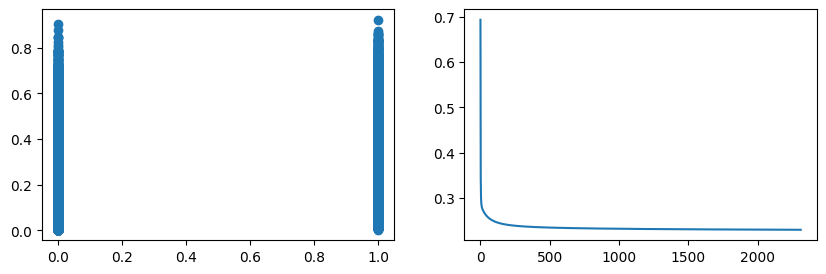

In [ ]:
y_pred = sigmoid(X_testN.dot(w))
plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(y_test, y_pred, 'o')

plt.subplot(1,2,2)
plt.plot(losses)

In [ ]:
y_pred_class = (y_pred >= 0.3).astype(int)
print(y_test[:5])
print(y_pred[:5])
print(y_pred_class[:5])


[0. 0. 1. 1. 0.]
[0.03605589 0.0468233  0.04931845 0.09151233 0.02270889]
[0 0 0 0 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9004565962578075


In [ ]:
Precision = metrics.precision_score(y_test, y_pred_class)
Recall = metrics.recall_score(y_test, y_pred_class)
F1 = metrics.f1_score(y_test, y_pred_class)

In [ ]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {Precision}")
print(f"Recall: {Recall}")
print(f"F1 Score: {F1}")

Accuracy: 0.9004565962578075
Precision: 0.40765357502517624
Recall: 0.31477449455676515
F1 Score: 0.3552435278630979


In [ ]:
print(metrics.classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95     67377
         1.0       0.41      0.31      0.36      6430

    accuracy                           0.90     73807
   macro avg       0.67      0.64      0.65     73807
weighted avg       0.89      0.90      0.89     73807



Our model has 91% accuracy, which looks good at first glance, but the classification report reveals an important problem.

The model is excellent at identifying Class 0.
It correctly finds 99% of all actual Class 0 cases.

**Recall = 0.11**
Your model identifies only: 11% of actual Class 1 cases. which means 5772 positive cases are being missed

**Precision = 0.54**
When the model predicts Class 1: only 54% of those predictions are correct.
This is okay, but not great.

**F1 Score = 0.18**
This is extremely low.
The model is heavily biased toward predicting Class 0.

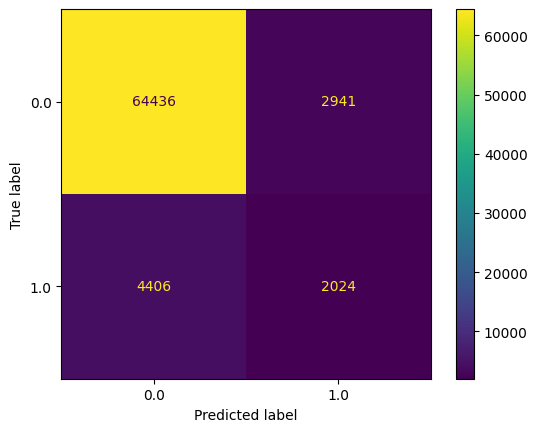

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class)
plt.show()

In [ ]:
y.value_counts(normalize=True)

,proportion
HeartDisease,
0,0.912138
1,0.087862
